## Air Quality
dataset: https://www.kaggle.com/datasets/tfisthis/global-air-quality-and-respiratory-health-outcomes?resource=download

- Conociendo los datos

In [49]:
# librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# dataset
dataset = pd.read_csv('air_quality_health_dataset.csv')
dataset.head() # viendo si se cargo de manera correcta los datos


,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631


In [50]:
dataset.shape # tamaño del dataset

(88489, 12)

In [51]:
dataset.info() # que tdatos tenemos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88489 entries, 0 to 88488
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 88489 non-null  object 
 1   date                 88489 non-null  object 
 2   aqi                  88489 non-null  int64  
 3   pm2_5                88489 non-null  float64
 4   pm10                 88489 non-null  float64
 5   no2                  88489 non-null  float64
 6   o3                   88489 non-null  float64
 7   temperature          88489 non-null  float64
 8   humidity             88489 non-null  int64  
 9   hospital_admissions  88489 non-null  int64  
 10  population_density   88489 non-null  object 
 11  hospital_capacity    88489 non-null  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 8.1+ MB


In [52]:
#observar los valores unicos
def get_unique_values (df):
  output_data = []
  for col in df.columns:
    # si el numero de valores unicos es menor o igual a 10
    if df.loc[ :, col].nunique() <=10:
      # obtenemos los valores unicos en la columna
      unique_values = df.loc[ :,col].unique()
      # agregamos  el nombre de la columa, el numero de valores
      # unicos y los datos unicos.
      output_data.append([col, df.loc[ :, col].nunique(),
                          unique_values, df.loc[ :, col].dtype])
    else:
        # en cada caso contrario, agrega solamente el nombre de la
        # columna, el numero de valores unicos y el tipo de dato.
        output_data.append([col, df.loc[ :, col].nunique(),
                            "-",df.loc[:, col].dtype])
  output_df = pd.DataFrame(output_data, columns = ["columns name",
                                                    "Number of unique Values", "Unique values",
                                                    "Data type"])
  return output_df


get_unique_values(dataset)

,columns name,Number of unique Values,Unique values,Data type
0,city,8,"[Los Angeles, Beijing, London, Mexico City, De...",object
1,date,88489,-,object
2,aqi,500,-,int64
3,pm2_5,872,-,float64
4,pm10,1188,-,float64
5,no2,653,-,float64
6,o3,825,-,float64
7,temperature,451,-,float64
8,humidity,75,-,int64
9,hospital_admissions,26,-,int64


In [53]:
dataset.describe().T # estadistica basica de los 
# - count: Número de valores no nulos
# - mean: Promedio o media aritmética
# - std: Desviación estándar (medida de dispersión)
# - min: Valor mínimo
# - 25%: Primer cuartil (percentil 25)
# - 50%: Mediana (percentil 50)
# - 75%: Tercer cuartil (percentil 75)
# - max: Valor máximo

,count,mean,std,min,25%,50%,75%,max
aqi,88489.0,249.370182,144.479132,0.0,124.0,249.0,374.0,499.0
pm2_5,88489.0,35.144951,14.767994,0.0,24.9,35.1,45.2,109.9
pm10,88489.0,50.118654,19.796392,0.0,36.6,50.0,63.5,143.5
no2,88489.0,30.006211,9.963139,0.0,23.3,30.0,36.7,71.4
o3,88489.0,39.978895,12.007258,0.0,31.9,40.0,48.1,93.5
temperature,88489.0,17.522962,12.961024,-5.0,6.4,17.5,28.7,40.0
humidity,88489.0,56.950966,21.629675,20.0,38.0,57.0,76.0,94.0
hospital_admissions,88489.0,8.049385,3.715458,0.0,6.0,8.0,10.0,25.0
hospital_capacity,88489.0,1024.463165,561.978071,50.0,539.0,1026.0,1511.0,1999.0


- Legibilidad y Visualizacion de los datos

In [54]:
# renombramiento a nombres en español y mas legibles 
dataset.rename(columns={
    'city': 'Ciudad',
    'date': 'Fecha',
    'aqi': 'Calidad_Aire',
    'pm2_5': 'Concentracion_PM2.5',
    'pm10': 'Concentracion_PM10',
    'no2': 'Concentracion_Dioxido_Nitrogeno',
    'o3': 'Concentracion_Ozono',
    'temperature': 'Temperatura',
    'humidity': 'Humedad',
    'hospital_admissions': 'Hospitalizaciones',
    'population_density': 'Densidad_Poblacional',
    'hospital_capacity': 'Capacidad_Hospitalaria'
}, inplace=True)

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88489 entries, 0 to 88488
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ciudad                           88489 non-null  object 
 1   Fecha                            88489 non-null  object 
 2   Calidad_Aire                     88489 non-null  int64  
 3   Concentracion_PM2.5              88489 non-null  float64
 4   Concentracion_PM10               88489 non-null  float64
 5   Concentracion_Dioxido_Nitrogeno  88489 non-null  float64
 6   Concentracion_Ozono              88489 non-null  float64
 7   Temperatura                      88489 non-null  float64
 8   Humedad                          88489 non-null  int64  
 9   Hospitalizaciones                88489 non-null  int64  
 10  Densidad_Poblacional             88489 non-null  object 
 11  Capacidad_Hospitalaria           88489 non-null  int64  
dtypes: float64(5), int

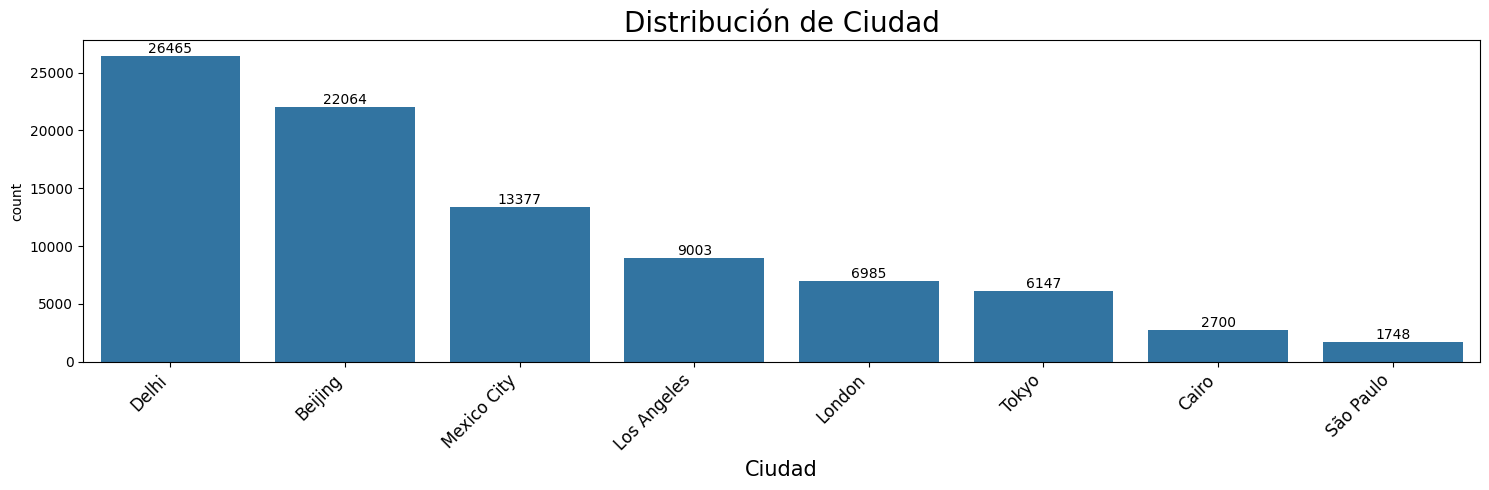

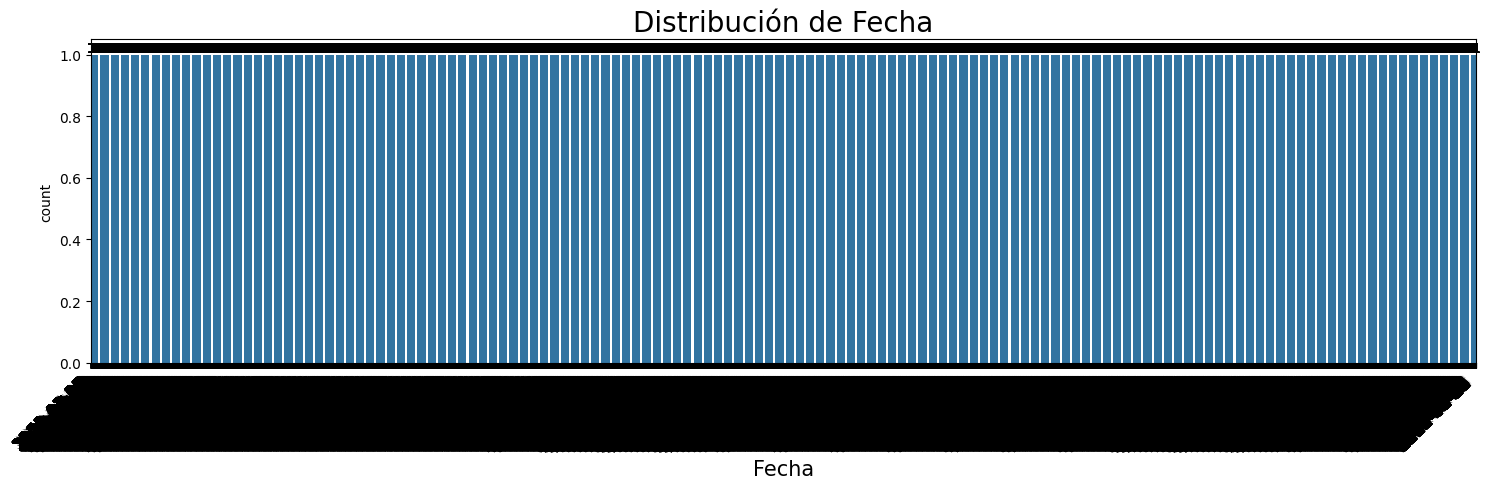

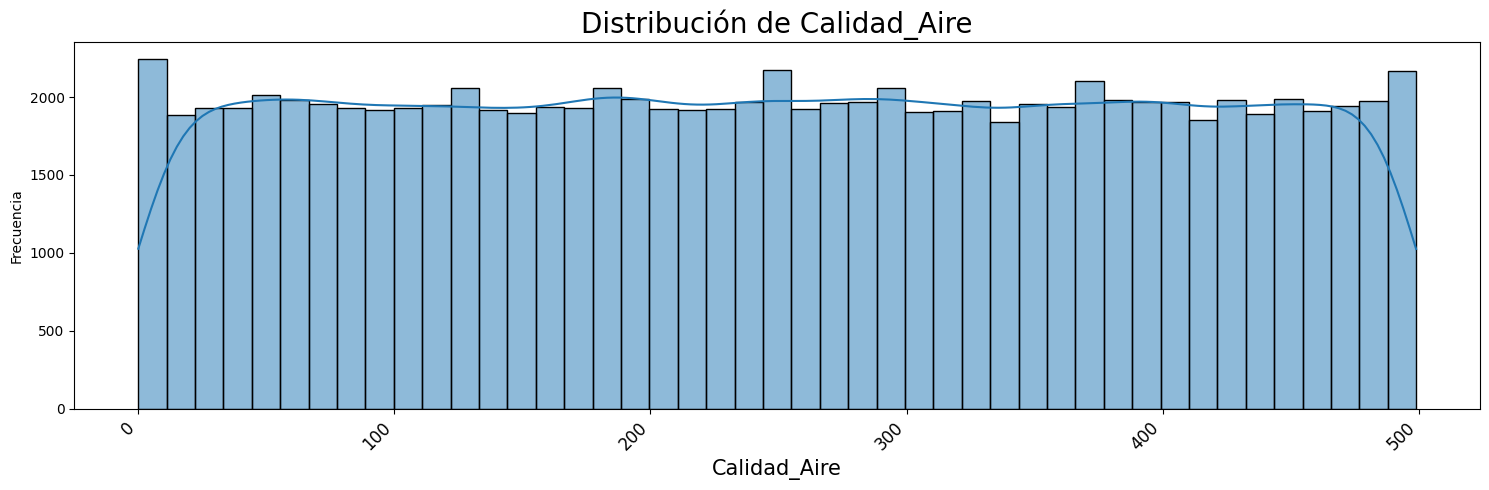

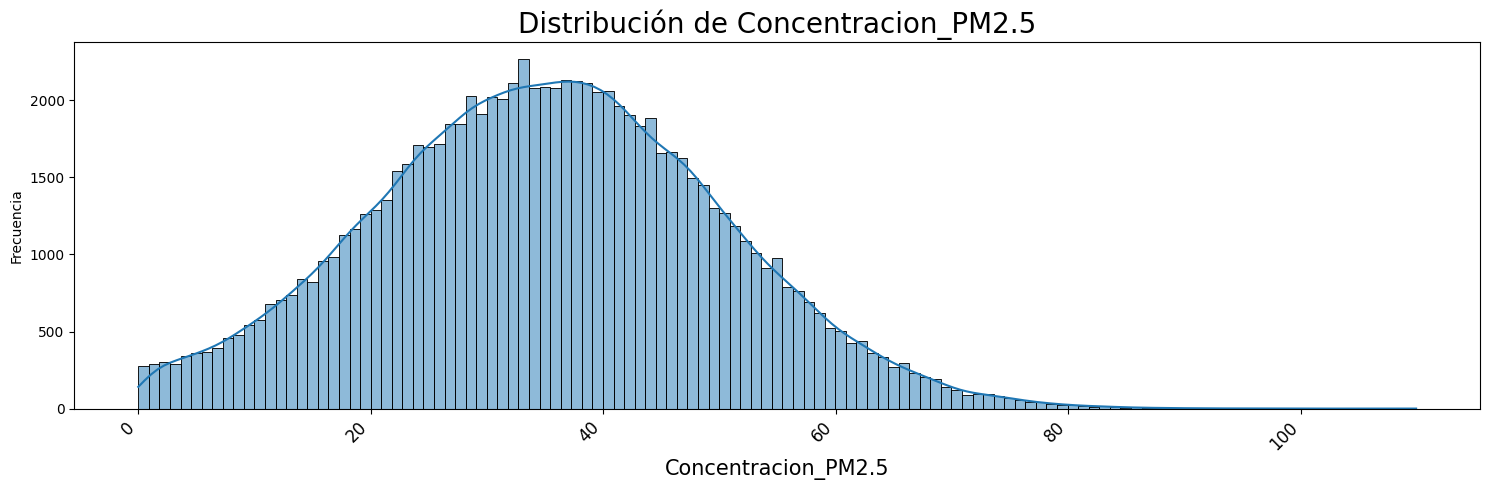

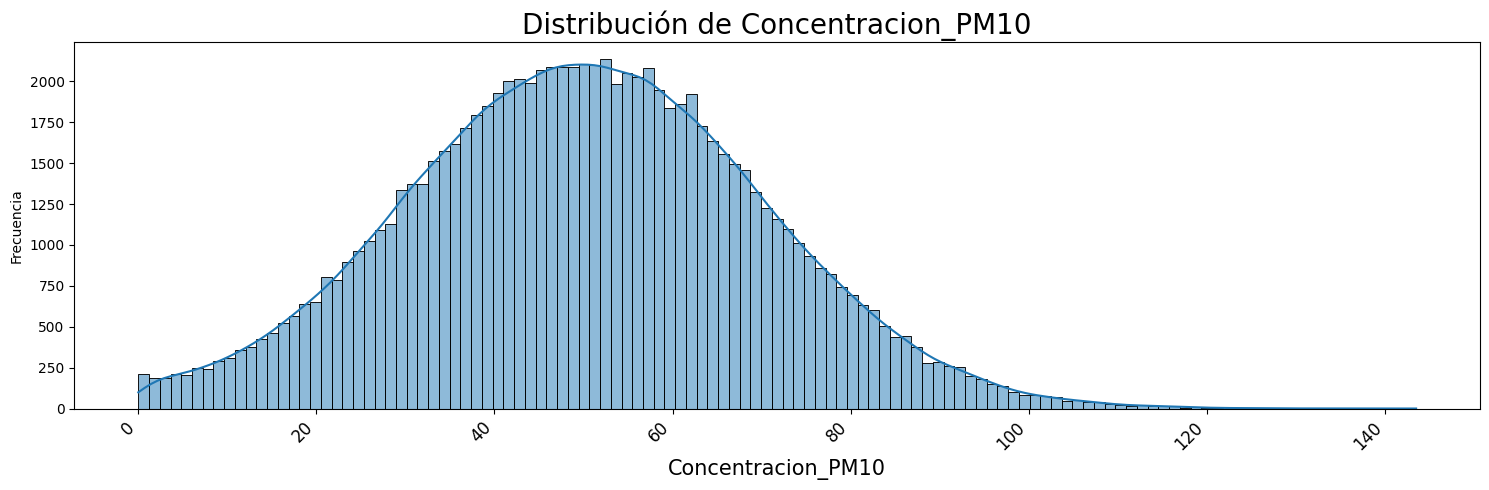

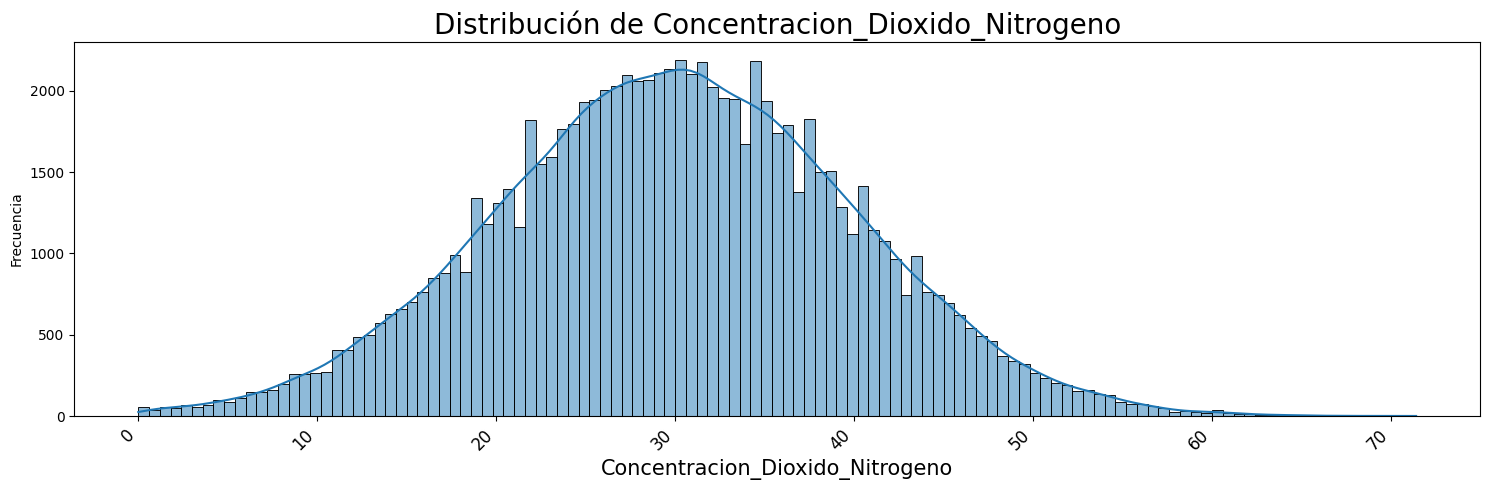

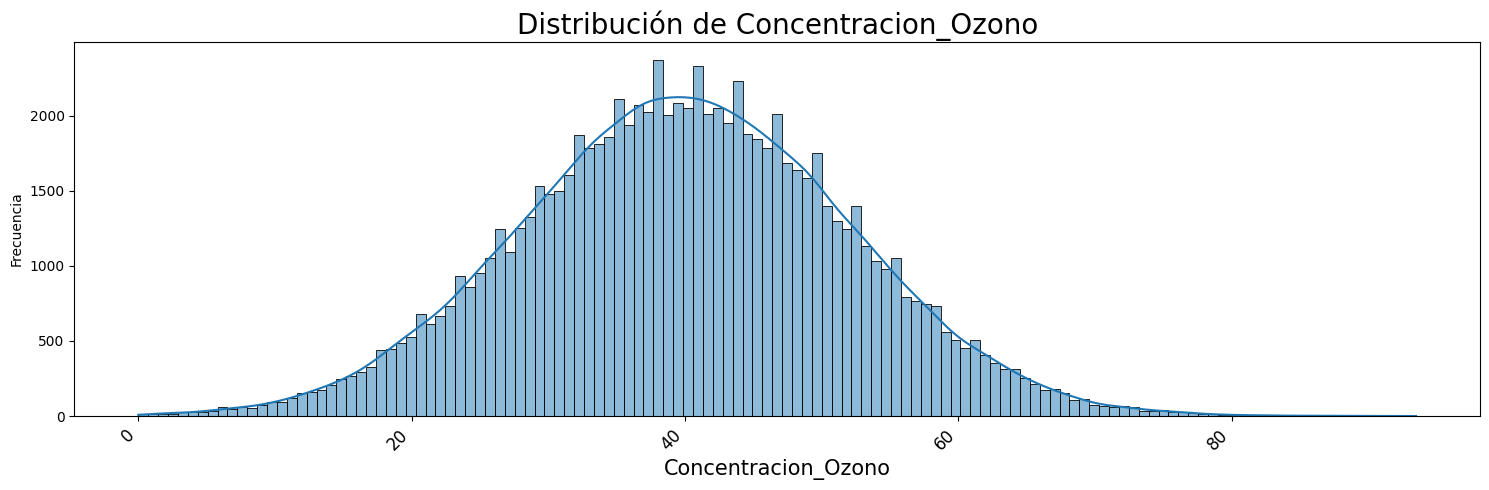

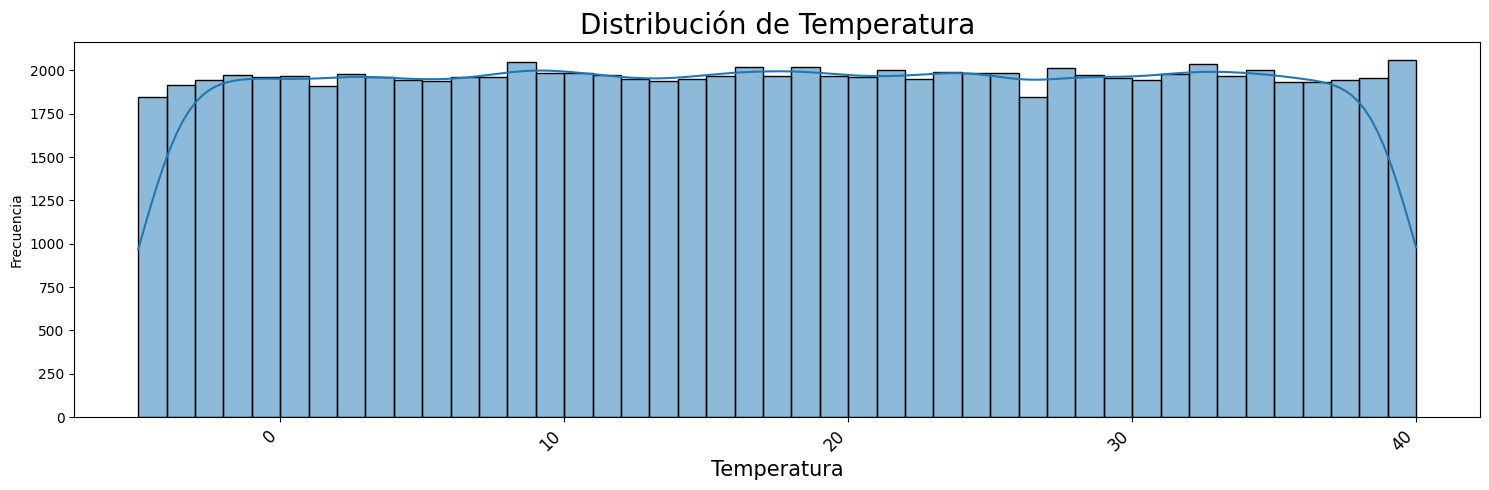

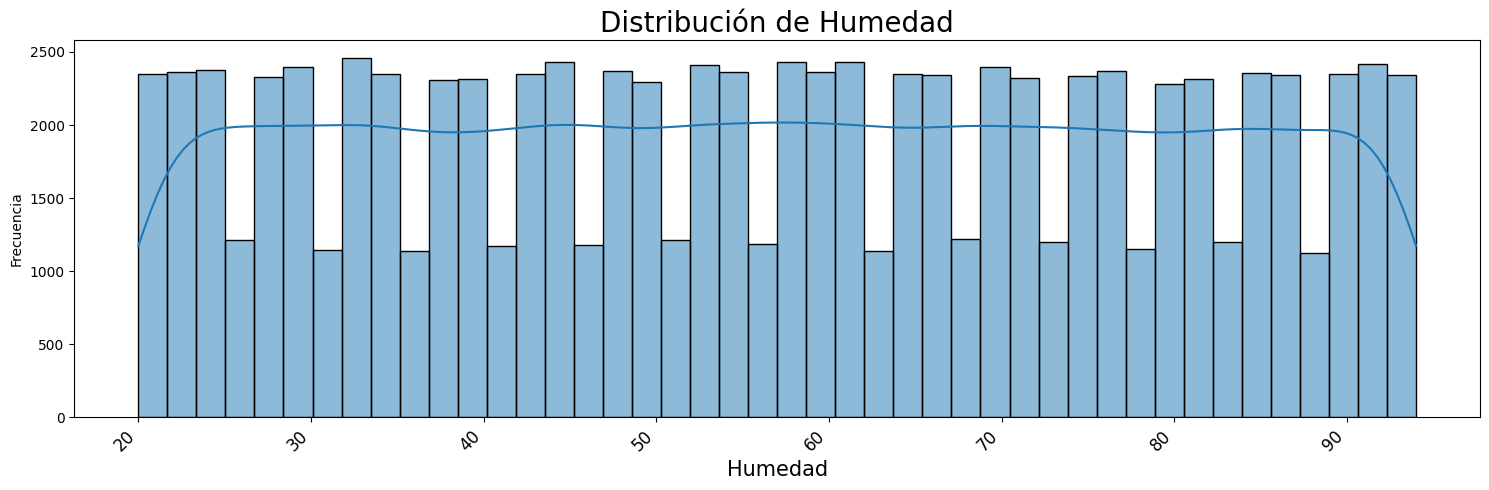

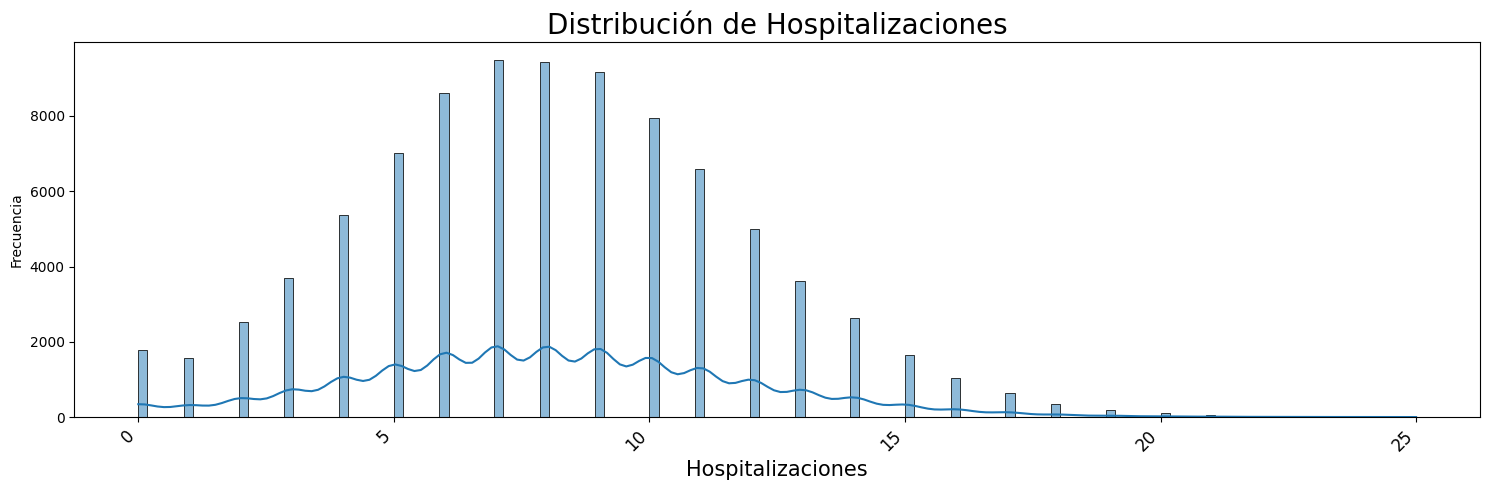

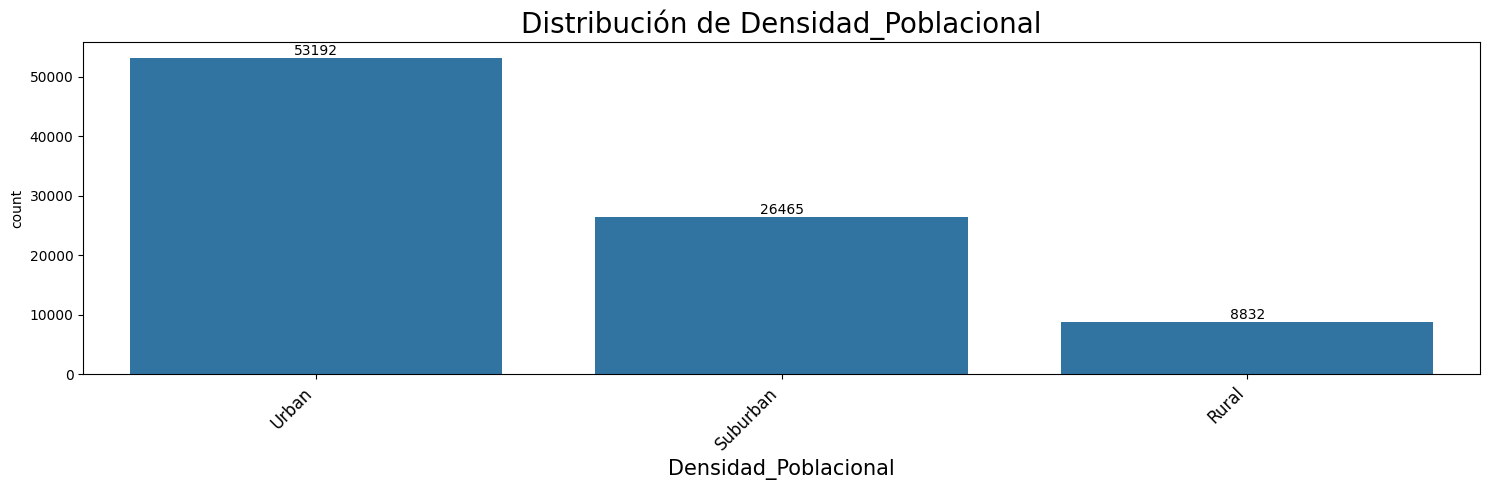

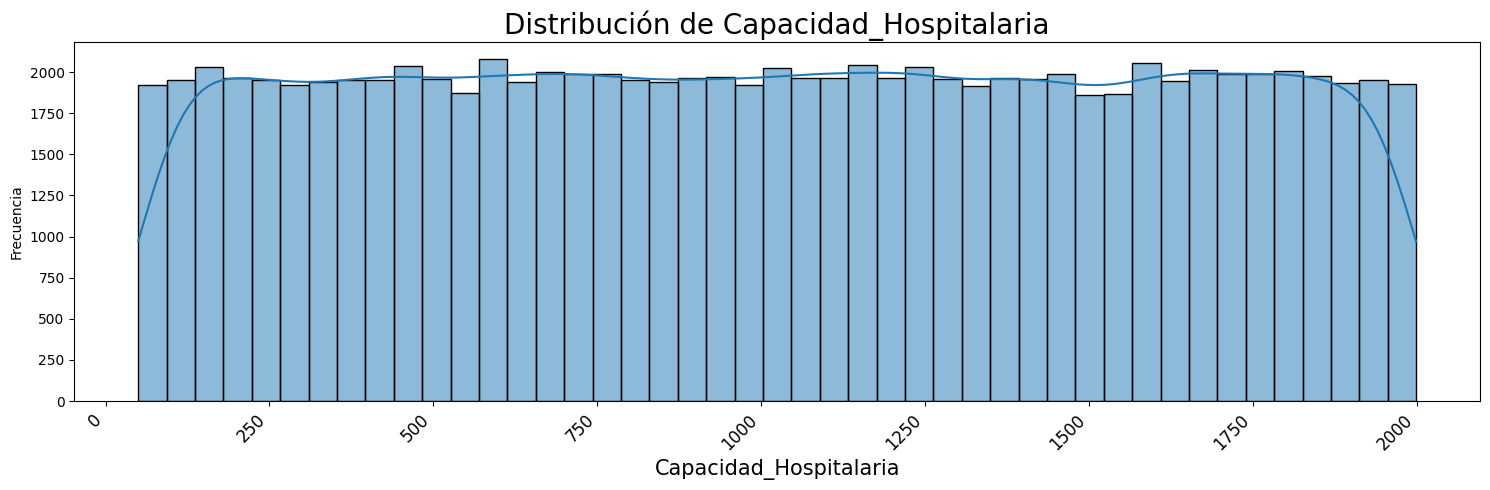

In [55]:
# Corrige los nombres de las columnas en tu lista
columnas_dataset = [
    'Ciudad',
    'Fecha',
    'Calidad_Aire',
    'Concentracion_PM2.5',
    'Concentracion_PM10',
    'Concentracion_Dioxido_Nitrogeno',
    'Concentracion_Ozono',
    'Temperatura',
    'Humedad',
    'Hospitalizaciones',
    'Densidad_Poblacional',
    'Capacidad_Hospitalaria'
]

# Función mejorada para gráficas
def grafica_barras(df, columns):
    for column in columns:
        plt.figure(figsize=(15, 5))
        
        # Para variables categóricas o discretas usa countplot
        if df[column].dtype == 'object' or df[column].nunique() < 20:
            ax = sns.countplot(x=column, data=df, 
                             order=df[column].value_counts().index)
            ax.bar_label(ax.containers[0])
        else:
            # Para variables numéricas continuas usa histplot
            sns.histplot(data=df, x=column, kde=True)
            plt.ylabel('Frecuencia')
        
        plt.xlabel(column, fontsize=15)
        plt.title(f'Distribución de {column}', fontsize=20)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.tight_layout()
        plt.show()

# Ejecutar la función
grafica_barras(dataset, columnas_dataset)

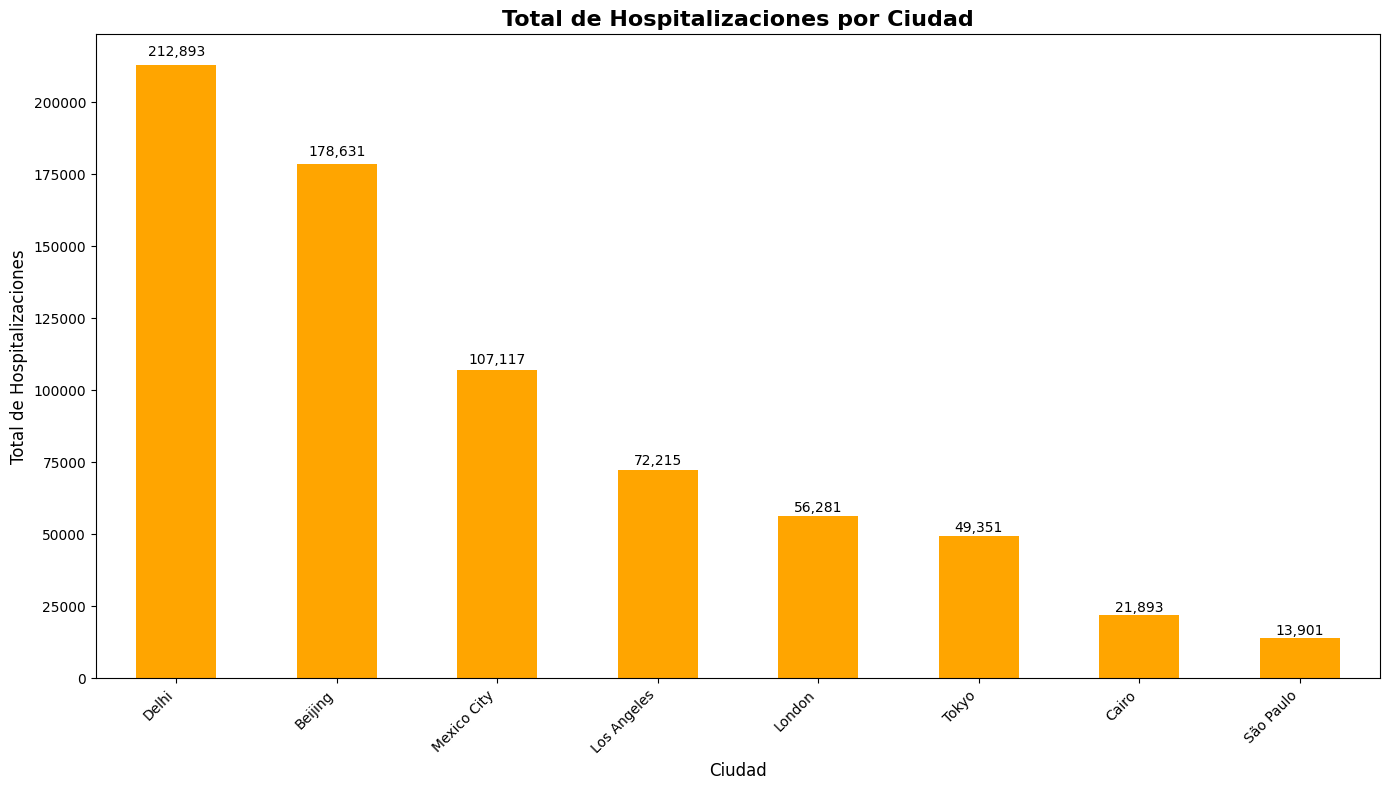

Top 15 Ciudades con más Hospitalizaciones:
Ciudad
Delhi          212893
Beijing        178631
Mexico City    107117
Los Angeles     72215
London          56281
Tokyo           49351
Cairo           21893
São Paulo       13901
Name: Hospitalizaciones, dtype: int64


In [56]:
# Gráfica por Ciudad
plt.figure(figsize=(14, 8))

# Top 15 ciudades con más hospitalizaciones
hospitalizaciones_por_ciudad = dataset.groupby('Ciudad')['Hospitalizaciones'].sum().sort_values(ascending=False).head(15)

ax = hospitalizaciones_por_ciudad.plot(kind='bar', color='orange')
plt.title('Total de Hospitalizaciones por Ciudad', fontsize=16, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Total de Hospitalizaciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Agregar valores en las barras
for i, v in enumerate(hospitalizaciones_por_ciudad):
    ax.text(i, v + (v * 0.01), f'{v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Top 15 Ciudades con más Hospitalizaciones:")
print(hospitalizaciones_por_ciudad)

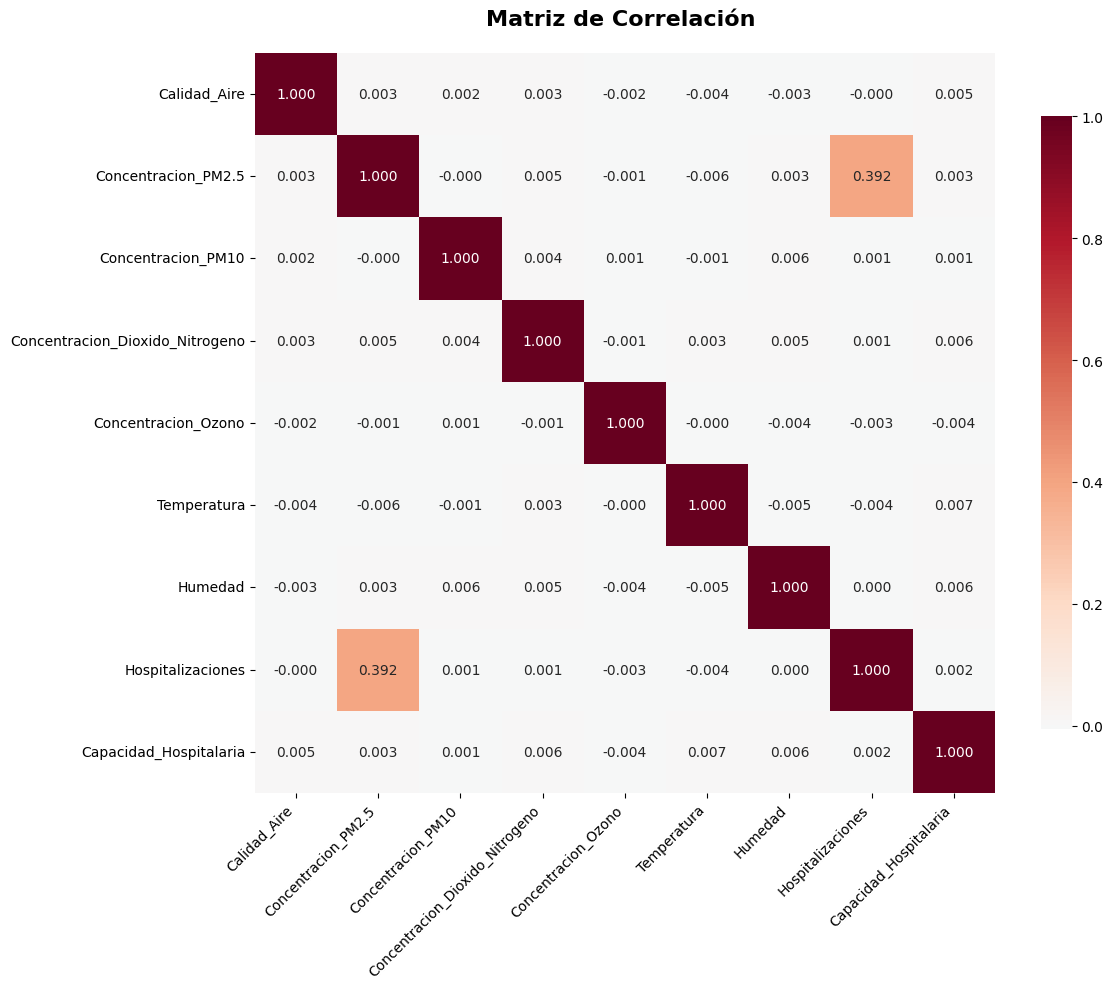

In [57]:
# Seleccionar solo las columnas numéricas para la matriz de correlación
columnas_numericas = [
    'Calidad_Aire',
    'Concentracion_PM2.5', 
    'Concentracion_PM10',
    'Concentracion_Dioxido_Nitrogeno',
    'Concentracion_Ozono',
    'Temperatura',
    'Humedad',
    'Hospitalizaciones',
    'Capacidad_Hospitalaria'
]

# Crear subdataset solo con columnas numéricas
dataset_numerico = dataset[columnas_numericas]

# Calcular matriz de correlación
matriz_correlacion = dataset_numerico.corr()

# Crear el heatmap COMPLETO (sin máscara)
plt.figure(figsize=(12, 10))

sns.heatmap(matriz_correlacion, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.3f',  # Mostrar 3 decimales
            square=True,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10})

plt.title('Matriz de Correlación ', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88489 entries, 0 to 88488
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ciudad                           88489 non-null  object 
 1   Fecha                            88489 non-null  object 
 2   Calidad_Aire                     88489 non-null  int64  
 3   Concentracion_PM2.5              88489 non-null  float64
 4   Concentracion_PM10               88489 non-null  float64
 5   Concentracion_Dioxido_Nitrogeno  88489 non-null  float64
 6   Concentracion_Ozono              88489 non-null  float64
 7   Temperatura                      88489 non-null  float64
 8   Humedad                          88489 non-null  int64  
 9   Hospitalizaciones                88489 non-null  int64  
 10  Densidad_Poblacional             88489 non-null  object 
 11  Capacidad_Hospitalaria           88489 non-null  int64  
dtypes: float64(5), int

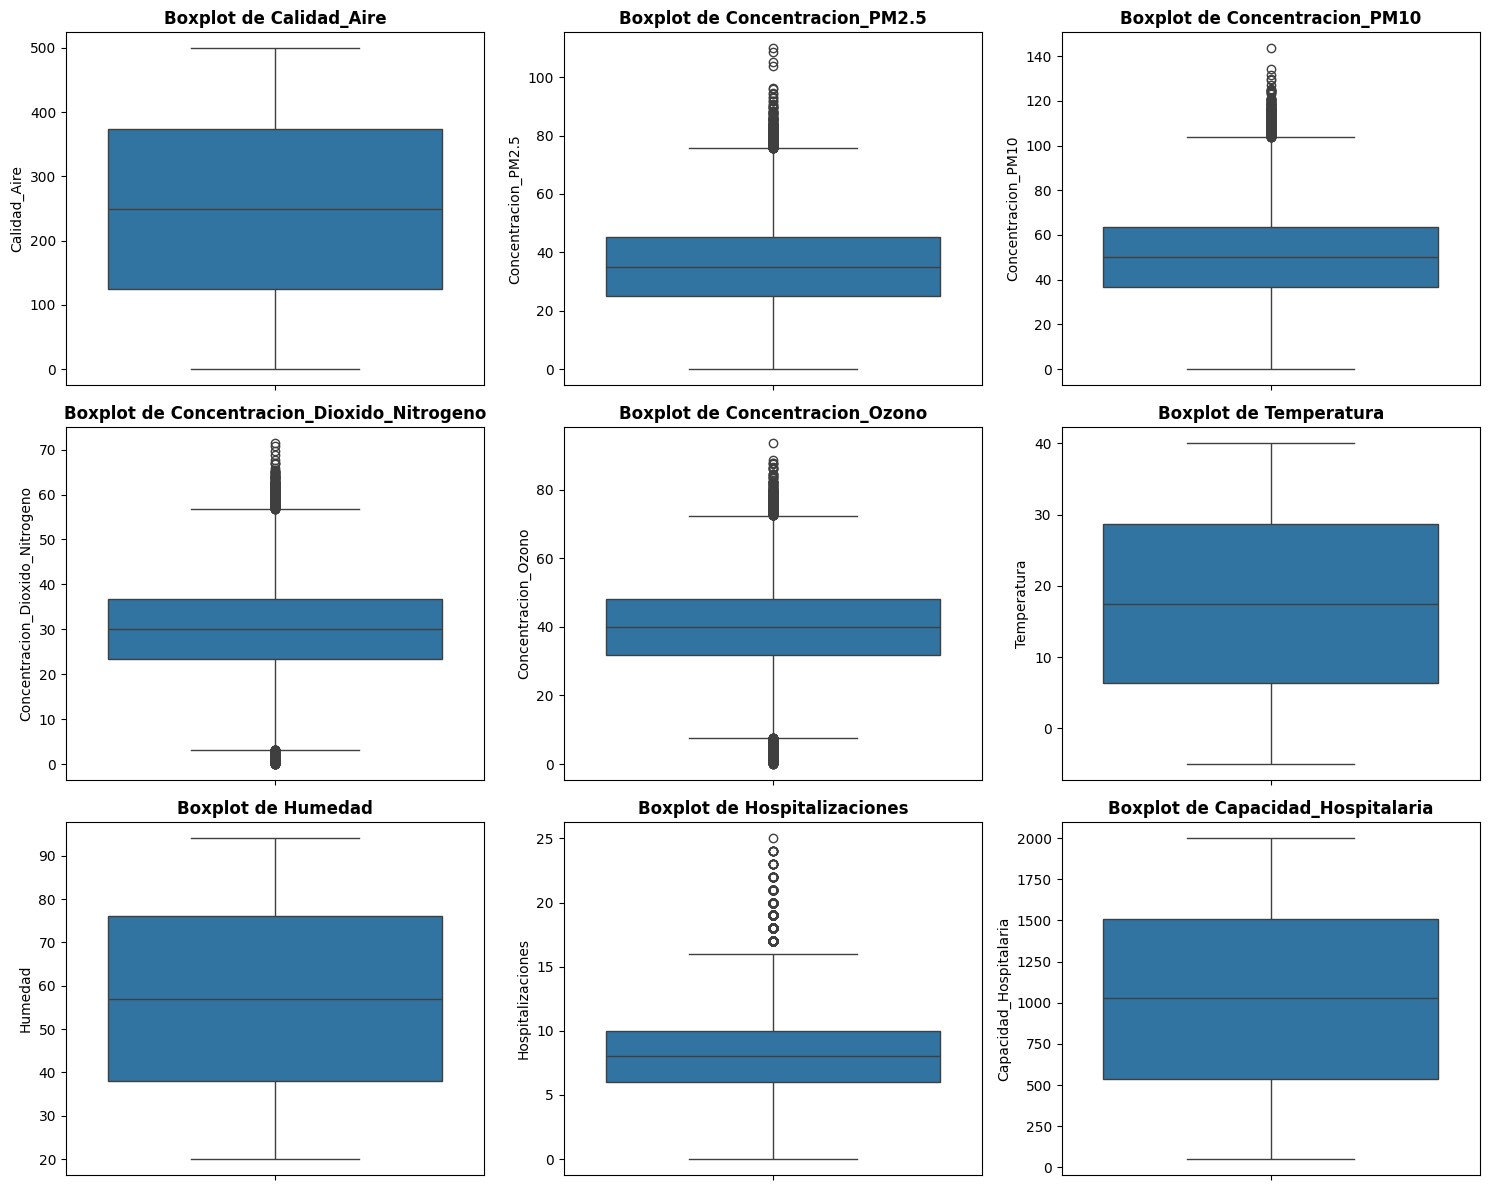

In [58]:
dataset.info()

n_columnas = 3  # Puedes ajustar este número
n_filas = int(np.ceil(len(columnas_numericas) / n_columnas))

# Crear la figura
plt.figure(figsize=(5 * n_columnas, 4 * n_filas))

# Crear boxplot para cada columna
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(n_filas, n_columnas, i)
    sns.boxplot(y=dataset[col])
    plt.title(f'Boxplot de {col}', fontweight='bold')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Proyecto mineria - Prediccion